# Image Processing Notebook

**Purpose:** Load medical/ophthalmology images, decompose into RGB channels, normalize to grayscale [0..1], and display results.

In [1]:
# ─── Cell 1: Imports ───
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

In [3]:
DATASET_PATH = "./data/original/im0001.ppm"
GOLD_STANDARD_PATH = "./data/labels/im0001.vk.ppm"

def load_image(filepath: str) -> np.ndarray:
    """Load image from filepath, returns RGB numpy array (H, W, 3) dtype=uint8."""
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Image not found: {filepath}")
    img = Image.open(filepath).convert("RGB")
    return np.array(img)

dataset_img = load_image(DATASET_PATH)
gold_standard_img = load_image(GOLD_STANDARD_PATH)

print(f"Dataset shape:      {dataset_img.shape}  dtype: {dataset_img.dtype}")
print(f"Gold standard shape: {gold_standard_img.shape}  dtype: {gold_standard_img.dtype}")

Dataset shape:      (605, 700, 3)  dtype: uint8
Gold standard shape: (605, 700, 3)  dtype: uint8


In [4]:
# ─── Cell 3: RGB channel decomposition ───

def decompose_rgb(image: np.ndarray):
    if image.ndim != 3 or image.shape[2] != 3:
        raise ValueError(f"Expected RGB image (H, W, 3), got shape {image.shape}")

    red   = image[:, :, 0]
    green = image[:, :, 1]
    blue  = image[:, :, 2]
    return red, green, blue

# ── Example usage ──
R, G, B = decompose_rgb(dataset_img)
print(f"Red channel shape:   {R.shape}")
print(f"Green channel shape: {G.shape}")
print(f"Blue channel shape:  {B.shape}")

Red channel shape:   (605, 700)
Green channel shape: (605, 700)
Blue channel shape:  (605, 700)


In [5]:
# ─── Cell 4: Normalize & convert to grayscale [0..1] ───

def normalize_grayscale(image: np.ndarray) -> np.ndarray:
    img = image.astype(np.float64)

    if img.ndim == 2:
        # Already single-channel
        gray = img
    elif img.ndim == 3 and img.shape[2] == 3:
        gray = 0.2989 * img[:, :, 0] + 0.5870 * img[:, :, 1] + 0.1140 * img[:, :, 2]
    else:
        raise ValueError(f"Unexpected image shape: {img.shape}")

    # Normalize uint8 range 0–255 → 0–1, or re-normalize any range to [0, 1]
    gray_min, gray_max = gray.min(), gray.max()
    if gray_max > gray_min:
        gray = (gray - gray_min) / (gray_max - gray_min)
    else:
        gray = np.zeros_like(gray)

    return gray

# ── Example usage ──
dataset_gray = normalize_grayscale(dataset_img)
gold_gray    = normalize_grayscale(gold_standard_img)

print(f"Dataset gray:      shape={dataset_gray.shape}, min={dataset_gray.min():.4f}, max={dataset_gray.max():.4f}")
print(f"Gold standard gray: shape={gold_gray.shape}, min={gold_gray.min():.4f}, max={gold_gray.max():.4f}")

Dataset gray:      shape=(605, 700), min=0.0000, max=1.0000
Gold standard gray: shape=(605, 700), min=0.0000, max=1.0000


In [ ]:
# ─── Cell 5: Variadic image display ───

def display_images(*images, titles=None, cmap="gray", figsize_per_image=(4, 4)):
    n = len(images)
    if n == 0:
        print("No images to display.")
        return

    if titles is None:
        titles = [f"Image {i + 1}" for i in range(n)]
    elif len(titles) != n:
        raise ValueError(f"Got {n} images but {len(titles)} titles")

    fig, axes = plt.subplots(1, n, figsize=(figsize_per_image[0] * n, figsize_per_image[1]))
    if n == 1:
        axes = [axes]  # keep iterable for single-image case

    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

Display function ready.


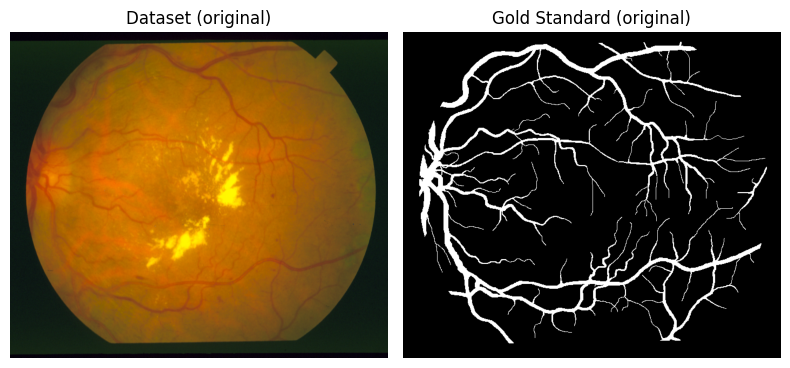

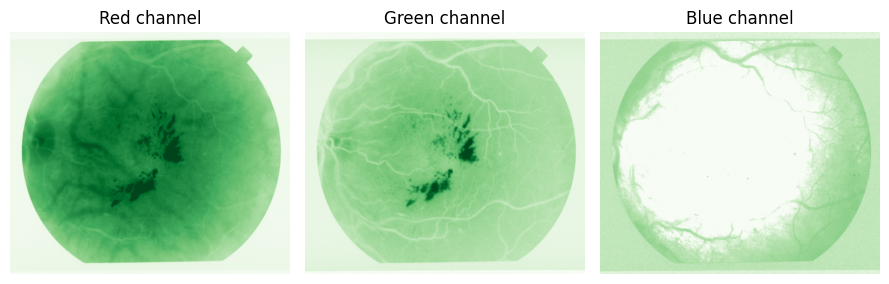

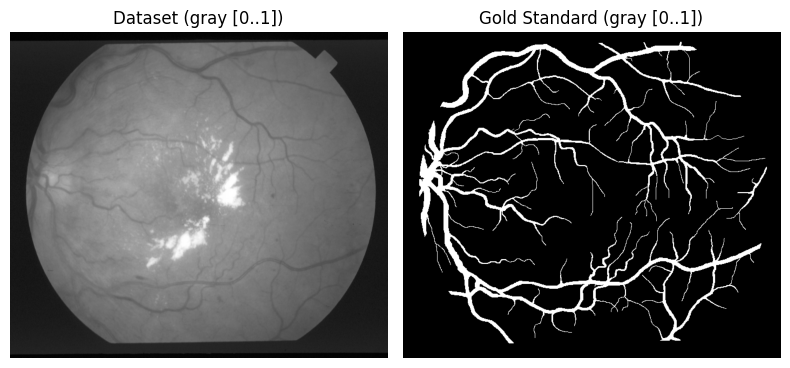

In [11]:
# ─── Cell 6: Demonstration — run after setting real filepaths ───

display_images(dataset_img, gold_standard_img,
               titles=["Dataset (original)", "Gold Standard (original)"],
               cmap=None)  # None = keep RGB colours

# Display RGB channel decomposition of dataset
R, G, B = decompose_rgb(dataset_img)
display_images(R, G, B,
               titles=["Red channel", "Green channel", "Blue channel"],
               cmap="Greens", figsize_per_image=(3, 3))

# Display normalized grayscale versions
display_images(dataset_gray, gold_gray,
               titles=["Dataset (gray [0..1])", "Gold Standard (gray [0..1])"],
               cmap="gray")

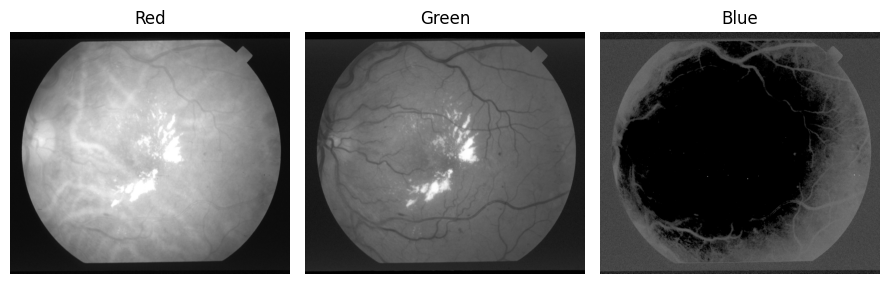

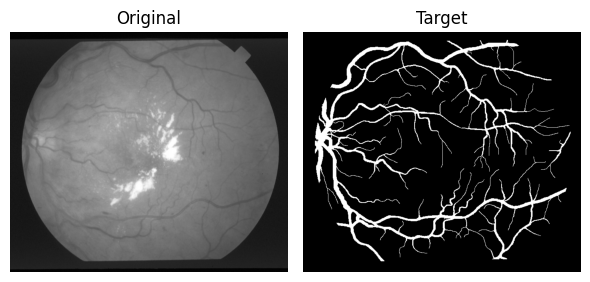

In [10]:
# ─── Cell 7 (bonus): Side-by-side RGB + grayscale comparison ───

R, G, B = decompose_rgb(dataset_img)
# gray = normalize_grayscale(dataset_img)

display_images(R, G, B,
               titles=["Red", "Green", "Blue"],
               cmap="gray",
               figsize_per_image=(3, 3))

display_images(dataset_gray, gold_gray,
               titles=["Original", "Target"],
               cmap="gray",
               figsize_per_image=(3, 3))
